# Information beyond global sensitivity

Supporting notebook for the manuscript subsection **Information beyond global sensitivity**.

A single scrambled Sobol sample with $N=2^{17}=131{,}072$ is generated for each benchmark model. The horizontal axis uses the **raw global combined sensitivity index** $S_i$. The vertical axis uses input-conditioned heterogeneity $H_{X_i}$ from the package. Output-conditioned $H_Y$ is not included in this comparison.

In [1]:
# Validation target. After PR #62 is merged, change only this value to "main"
# and rerun the notebook from a fresh kernel.
SIMDEC_REF = "heterogeneity-index-update"
SIMDEC_REPO = "https://github.com/Simulation-Decomposition/simdec-python.git"

import subprocess
import sys

# Reinstall only SimDec from the selected Git ref.  --no-deps is intentional:
# it avoids replacing NumPy/SciPy inside a running notebook kernel.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
    "--no-deps", "--force-reinstall", f"git+{SIMDEC_REPO}@{SIMDEC_REF}"
])

0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import qmc
from IPython.display import display


import json
from importlib.metadata import distribution, version

import simdec as sd

assert callable(getattr(sd, "sensitivity_indices", None))
assert callable(getattr(sd, "heterogeneity_indices", None))

dist = distribution("simdec")
print("SimDec version:", version("simdec"))
print("SimDec module:", sd.__file__)

direct_url = dist.read_text("direct_url.json")
if direct_url:
    print("Installation provenance:")
    print(json.dumps(json.loads(direct_url), indent=2))
else:
    print("No direct_url.json was found for this installation.")


N = 2**17
M = 17
N_REGIONS = 5
SEED = 20260912
CMAP = plt.colormaps["terrain"]

def variable_label(name):
    return rf"$X_{{{name[1:]}}}$"

SimDec version: 1.5.1
SimDec module: /usr/local/lib/python3.13/dist-packages/simdec/__init__.py
Installation provenance:
{
  "url": "https://github.com/Simulation-Decomposition/simdec-python.git",
  "vcs_info": {
    "commit_id": "6fcd6622d93513c7fafbe6dd3b57dd9a38aad620",
    "requested_revision": "heterogeneity-index-update",
    "vcs": "git"
  }
}


In [3]:
# Benchmark definitions used in Sections 2--4.
def binary_model(x):
    # X1=A, X2=K, X3=B; a=4.
    return x[:, 0] + (1 + 4 * x[:, 1]) * x[:, 2]


def f1(x):
    return 10 * x[:, 0] + 0.5 * x[:, 1] ** 3


def f2(x):
    return 2 * x[:, 0] - x[:, 1] ** 2


def f3(x):
    x1, x2, x3 = x.T
    return x1**2 + x2**4 + x1 * x2 + x2 * x3**4


def f4(x):
    x1, x2 = x.T
    return (
        0.2 * np.exp(x1 - 3)
        + 2.2 * np.abs(x2)
        + 1.3 * x2**6
        - 2 * x2**2
        - 0.5 * x2**4
        - 0.5 * x1**4
        + 2.5 * x1**2
        + 0.7 * x1**3
        + 3 / ((8 * x1 - 2) ** 2 + (5 * x2 - 3) ** 2 + 1)
        + np.sin(5 * x1) * np.cos(3 * x1**2)
    )


def ishigami(x):
    x1, x2, x3 = x.T
    return np.sin(x1) + 7 * np.sin(x2) ** 2 + 0.1 * x3**4 * np.sin(x1)


def hartmann6(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    a = np.array([
        [10, 3, 17, 3.50, 1.7, 8],
        [0.05, 10, 17, 0.1, 8, 14],
        [3, 3.5, 1.7, 10, 17, 8],
        [17, 8, 0.05, 10, 0.1, 14],
    ])
    p = 1e-4 * np.array([
        [1312, 1696, 5569, 124, 8283, 5886],
        [2329, 4135, 8307, 3736, 1004, 9991],
        [2348, 1451, 3522, 2883, 3047, 6650],
        [4047, 8828, 8732, 5743, 1091, 381],
    ])
    exponent = -np.sum(a[None, :, :] * (x[:, None, :] - p[None, :, :]) ** 2, axis=2)
    return -np.sum(alpha[None, :] * np.exp(exponent), axis=1)


def kriging(x):
    x1, x2, x3, x4 = x.T
    return (
        1
        + np.exp(-2 * ((x1 - 1) ** 2 + x2**2) - 0.5 * (x3**2 + x4**2))
        + np.exp(-2 * (x1**2 + (x2 - 1) ** 2) - 0.5 * (x3**2 + x4**2))
    )


def owen(x):
    tau = np.array([1, 1, 0.5, 0.5, 0.25, 0.25])
    return np.prod(1 + tau * np.sqrt(12) * (x - 0.5), axis=1)


F4_BOUNDS = (-1.0, 1.0)
BENCHMARKS = {
    "Binary": {"function": binary_model, "d": 3, "bounds": (0, 1), "binary_col": 1},
    "F1": {"function": f1, "d": 2, "bounds": (-5, 5)},
    "F2": {"function": f2, "d": 2, "bounds": (-5, 5)},
    "F3": {"function": f3, "d": 3, "bounds": (-4, 4)},
    "F4": {"function": f4, "d": 2, "bounds": F4_BOUNDS},
    "Ishigami": {"function": ishigami, "d": 3, "bounds": (-np.pi, np.pi)},
    "Hartmann 6-D": {"function": hartmann6, "d": 6, "bounds": (0, 1)},
    "Kriging": {"function": kriging, "d": 4, "bounds": (0, 1)},
    "Owen": {"function": owen, "d": 6, "bounds": (0, 1)},
}
FUNCTION_NAMES = list(BENCHMARKS)
FUNCTION_TITLES = {name: name for name in FUNCTION_NAMES}
FUNCTION_TITLES["Binary"] = "Binary model ($a=4$)"

In [4]:
rows = []
for f_idx, name in enumerate(FUNCTION_NAMES):
    spec = BENCHMARKS[name]
    u = qmc.Sobol(d=spec["d"], scramble=True, seed=SEED + f_idx).random_base2(M)
    low, high = spec["bounds"]
    x = low + (high - low) * u
    if "binary_col" in spec:
        j = spec["binary_col"]
        x[:, j] = (u[:, j] >= 0.5).astype(int)
    X = pd.DataFrame(x, columns=[f"X{i+1}" for i in range(spec["d"])])
    y = pd.Series(spec["function"](x), name="Y")

    global_res = sd.sensitivity_indices(inputs=X, output=y)
    global_si = pd.Series(np.asarray(global_res.si, dtype=float).ravel(), index=X.columns)
    H = sd.heterogeneity_indices(output=y, inputs=X, n_regions=N_REGIONS)

    for variable in X.columns:
        rows.append({"function": name, "variable": variable, "S_i": float(global_si[variable]), "H": float(H.indices[variable])})

si_h = pd.DataFrame(rows)
display(si_h.style.format({"S_i": "{:.4f}", "H": "{:.4f}"}))
assert np.isfinite(si_h[["S_i", "H"]].to_numpy()).all()

,function,variable,S_i,H
0,Binary,X1,0.0385,0.0001
1,Binary,X2,0.5381,0.4615
2,Binary,X3,0.4227,0.3116
3,F1,X1,0.5989,0.0000
4,F1,X2,0.4010,0.1128
5,F2,X1,0.3750,0.0000
6,F2,X2,0.6249,0.2057
7,F3,X1,0.0009,0.0117
8,F3,X2,0.6992,0.2841
9,F3,X3,0.2709,0.0554


## Figure 6

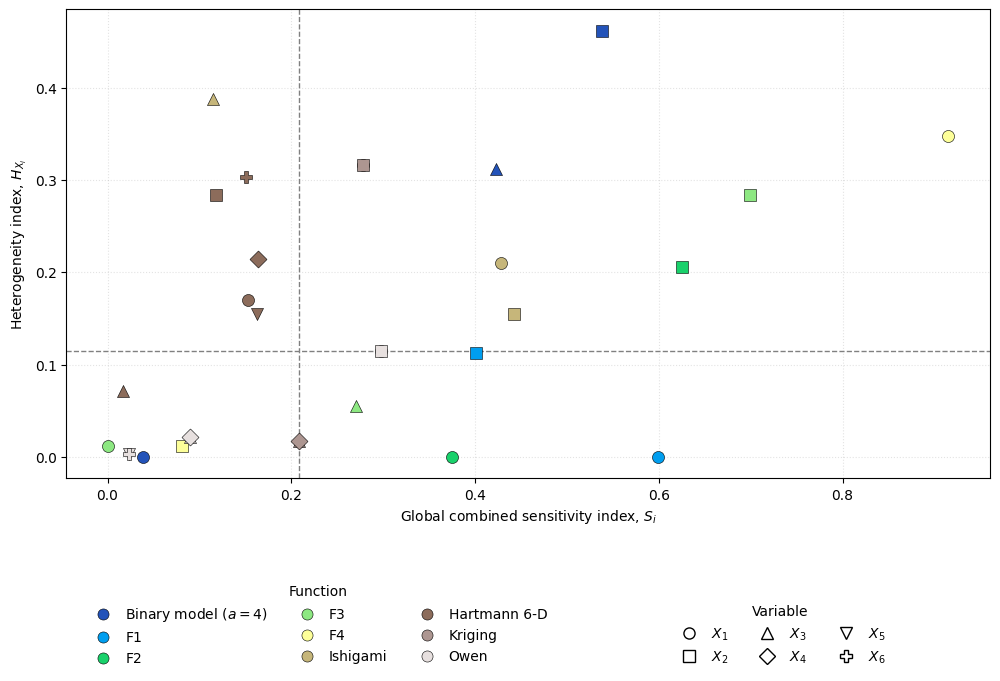

In [6]:
# Figure h6.
fig, ax = plt.subplots(figsize=(10.5, 7))

function_colors = {
    name: CMAP(pos)
    for name, pos in zip(
        FUNCTION_NAMES,
        np.linspace(0.05, 0.95, len(FUNCTION_NAMES)),
    )
}

markers = {
    "X1": "o",
    "X2": "s",
    "X3": "^",
    "X4": "D",
    "X5": "v",
    "X6": "P",
}

for name in FUNCTION_NAMES:
    view = si_h.loc[si_h["function"] == name]

    for _, row in view.iterrows():
        ax.scatter(
            row["S_i"],
            row["H"],
            color=function_colors[name],
            marker=markers.get(row["variable"], "o"),
            s=75,
            edgecolor="black",
            linewidth=0.4,
            zorder=3,
        )

# Function legend: color identifies the benchmark function.
function_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=function_colors[f],
        markeredgecolor="black",
        markeredgewidth=0.4,
        markersize=8,
        label=FUNCTION_TITLES[f],
    )
    for f in FUNCTION_NAMES
]

# Variable legend: marker shape identifies the input.
vars_present = sorted(
    si_h["variable"].unique(),
    key=lambda x: int(x[1:]),
)

variable_handles = [
    Line2D(
        [0],
        [0],
        marker=markers.get(v, "o"),
        linestyle="",
        color="black",
        markerfacecolor="white",
        markeredgewidth=1.0,
        markersize=8,
        label=variable_label(v),
    )
    for v in vars_present
]

# Exploratory median guides.
s_cut = si_h["S_i"].median()
h_cut = si_h["H"].median()

ax.axvline(
    s_cut,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax.axhline(
    h_cut,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(r"Global combined sensitivity index, $S_i$")
ax.set_ylabel(r"Heterogeneity index, $H_{X_i}$")
ax.grid(linestyle=":", alpha=0.35)
ax.set_axisbelow(True)

# Legends below the plot, matching the manuscript.
fig.legend(
    handles=function_handles,
    title="Function",
    loc="lower center",
    bbox_to_anchor=(0.34, 0.015),
    ncol=3,
    frameon=False,
    columnspacing=1.8,
    handletextpad=0.6,
)

fig.legend(
    handles=variable_handles,
    title="Variable",
    loc="lower center",
    bbox_to_anchor=(0.78, 0.015),
    ncol=3,
    frameon=False,
    columnspacing=1.8,
    handletextpad=0.6,
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.97,
    bottom=0.30,
)

plt.show()

Figure 6: Relationship between global sensitivity and heterogeneity across all benchmark functions.